# mmBERT GPU Throughput Saturation Sweep

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: 0 - encoder performance characterization

Pushes batch size from 1 upward until the GPU saturates, measuring **throughput (sentences/sec)** and **average latency (ms/sentence)** at each step, for both bf16-compiled and FP8-compiled mmBERT. The goal is the saturation *curve* - where the per-sentence cost stops falling and the GPU is fully utilized - so the headroom (the ramp) and the ceiling (the plateau) are both visible. This answers the standing question: single-request latency hides quantization's value, but at scale the throughput picture is different.

## Approach
1. **Build** bf16-compiled and FP8-compiled encoders on the Ada (`torch.compile` fuses the kernels)
2. **Sweep** batch size over a geometric range at fixed sequence length, measuring throughput, ms/sentence, and peak GPU memory; stop a scheme at OOM
3. **Find saturation** - the batch where throughput reaches ~95% of its peak (the knee), and the headroom ratio (peak/single-sentence throughput)
4. **Plot** throughput-vs-batch and ms/sentence-vs-batch so the ramp and plateau are explicit

## Outputs
- `reports/03-mmbert-throughput-saturation.json` - per-batch throughput / latency / memory for each scheme
- Throughput and latency curves with the saturation knee marked

## GPU Selection and Compiler

Ada (index 2), with `CC`/`CXX` for `torch.compile` and a raised TorchDynamo cache limit so each batch shape can compile without evicting the others.

In [1]:
import glob
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu
os.environ["TOKENIZERS_PARALLELISM"] = "false"
_cc = glob.glob("/opt/conda/bin/cc") or glob.glob("/opt/conda/bin/*-gcc")
_cxx = glob.glob("/opt/conda/bin/c++") or glob.glob("/opt/conda/bin/*-g++")
if _cc:
    os.environ["CC"] = _cc[0]
if _cxx:
    os.environ["CXX"] = _cxx[0]

import torch
import torch._dynamo
torch._dynamo.config.cache_size_limit = 128      # one compiled graph per batch shape
print("CC =", os.environ.get("CC"))

CC = /opt/conda/bin/cc


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import copy
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch.nn.functional as F
from transformers import AutoConfig, AutoModel, AutoTokenizer
from torchao.quantization import quantize_, Float8DynamicActivationFloat8WeightConfig

from rich import print as rprint
from rich.console import Console
from rich.table import Table

console = Console()

W0617 21:19:53.217000 222006 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


## Reproducibility

In [3]:
import random
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

## Configuration

Fixed sequence length, a geometric batch ladder, and the two schemes. The batch ladder is dense through the ramp and sparse through the plateau; OOM stops a scheme early and is recorded as the ceiling. `SATURATION_FRAC` defines the knee - the first batch reaching that fraction of peak throughput.

In [4]:
MODEL_NAME = "jhu-clsp/mmBERT-base"
SEQ = 128
REPEATS = 8
BATCH_SIZES = [1, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
SATURATION_FRAC = 0.95

PROJ_ROOT = Path.cwd().parent
OUT_PATH = PROJ_ROOT / "reports" / "03-mmbert-throughput-saturation.json"

device = torch.device("cuda")
rprint(f"""[bold medium_purple]Configuration[/bold medium_purple]
[dim]{"─" * 40}[/dim]
  Model: [cadet_blue]{MODEL_NAME}[/cadet_blue]   seq: [dark_sea_green]{SEQ}[/dark_sea_green]
  Batches: [grey70]{BATCH_SIZES}[/grey70]
  GPU: [cadet_blue]{torch.cuda.get_device_name(0)}[/cadet_blue] [light_sea_green]{torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB[/light_sea_green]
""")

Configuration
────────────────────────────────────────
  Model: jhu-clsp/mmBERT-base   seq: 128
  Batches: [1, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
  GPU: NVIDIA RTX 5000 Ada Generation 34 GB

## Build Encoders

Loads mmBERT in bf16, builds an FP8-quantized copy, and `torch.compile`s both. ModernBERT compile-hang guards stay on (`reference_compile=False`, eager attention).

In [5]:
cfg = AutoConfig.from_pretrained(MODEL_NAME); cfg.reference_compile = False
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bf16 = (AutoModel.from_pretrained(MODEL_NAME, config=cfg, attn_implementation="eager",
                                  torch_dtype=torch.bfloat16).to(device).eval())
fp8 = copy.deepcopy(bf16)
quantize_(fp8, Float8DynamicActivationFloat8WeightConfig())

MODELS = {"bf16_compiled": torch.compile(bf16), "fp8_compiled": torch.compile(fp8)}
rprint("[dark_sea_green]✓[/dark_sea_green] bf16 + fp8 encoders compiled")

W0617 21:19:56.694000 222006 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ bf16 + fp8 encoders compiled

## Benchmark Function

For a given model and batch, runs a fixed-shape forward (warmup absorbs compilation), times the median over `REPEATS`, and reports throughput, ms/sentence, and peak GPU memory. OOM is caught and signaled so the sweep stops cleanly at the ceiling.

In [6]:
@torch.no_grad()
def bench(model, batch, seq=SEQ, repeats=REPEATS):
    txt = ["enterprise ai adoption deployment integration outcomes across teams and regions over quarters"] * batch
    e = tokenizer(txt, return_tensors="pt", padding="max_length", truncation=True, max_length=seq).to(device)
    torch.cuda.reset_peak_memory_stats()
    for _ in range(2):
        model(**e).last_hidden_state.sum()        # warmup + compile
    torch.cuda.synchronize()
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        model(**e).last_hidden_state.sum()
        torch.cuda.synchronize()
        ts.append(time.perf_counter() - t0)
    ts.sort()
    med = ts[len(ts) // 2]
    return {
        "sent_per_s": batch / med,
        "ms_per_sent": med / batch * 1000.0,
        "peak_gb": torch.cuda.max_memory_allocated() / 1e9,
    }

## Sweep

Runs every batch for every scheme, stopping a scheme at OOM. Each result prints as it lands so progress is visible during the long compile-heavy run.

In [7]:
results = {name: {} for name in MODELS}
for name, model in MODELS.items():
    rprint(f"[bold slate_blue1]{name}[/bold slate_blue1]")
    for b in BATCH_SIZES:
        try:
            r = bench(model, b)
            results[name][b] = r
            rprint(f"  batch [dark_sea_green]{b:5d}[/dark_sea_green]  "
                   f"[dark_sea_green]{r['sent_per_s']:8.0f}[/dark_sea_green] sent/s  "
                   f"[steel_blue]{r['ms_per_sent']:.4f}[/steel_blue] ms/sent  "
                   f"[grey70]{r['peak_gb']:.1f} GB[/grey70]")
        except RuntimeError as ex:
            if "out of memory" in str(ex).lower():
                rprint(f"  batch [indian_red]{b:5d}  OOM (ceiling)[/indian_red]")
                torch.cuda.empty_cache()
                break
            raise

bf16_compiled

batch     1       206 sent/s  4.8613 ms/sent  1.2 GB

batch     4       856 sent/s  1.1677 ms/sent  1.2 GB

batch     8      1460 sent/s  0.6849 ms/sent  1.2 GB

batch    16      2007 sent/s  0.4983 ms/sent  1.2 GB

...

batch   256      2187 sent/s  0.4573 ms/sent  1.6 GB

batch   512      2134 sent/s  0.4687 ms/sent  2.0 GB

batch  1024      2123 sent/s  0.4711 ms/sent  3.0 GB

batch  2048      2119 sent/s  0.4720 ms/sent  4.8 GB

batch  4096      2115 sent/s  0.4727 ms/sent  8.4 GB

## Saturation Analysis

For each scheme: peak throughput, the saturation knee (first batch at `SATURATION_FRAC` of peak), the best (lowest) ms/sentence, and the headroom ratio - how many times faster the saturated GPU is than single-sentence serving.

In [8]:
summary = {}
for name, rs in results.items():
    if not rs:
        continue
    batches = sorted(rs)
    tps = [rs[b]["sent_per_s"] for b in batches]
    peak_tp = max(tps)
    knee = next(b for b in batches if rs[b]["sent_per_s"] >= SATURATION_FRAC * peak_tp)
    best_ms = min(rs[b]["ms_per_sent"] for b in batches)
    summary[name] = {
        "peak_sent_per_s": peak_tp,
        "saturation_batch": knee,
        "best_ms_per_sent": best_ms,
        "single_sent_per_s": rs[batches[0]]["sent_per_s"],
        "headroom_x": peak_tp / rs[batches[0]]["sent_per_s"],
        "max_batch_before_oom": batches[-1],
    }

table = Table(title=f"Saturation (seq {SEQ})")
table.add_column("scheme", style="grey70")
table.add_column("peak sent/s", style="dark_sea_green", justify="right")
table.add_column("knee batch", style="steel_blue", justify="right")
table.add_column("best ms/sent", style="dark_sea_green", justify="right")
table.add_column("headroom", style="dark_sea_green", justify="right")
for name, s in summary.items():
    table.add_row(name, f"{s['peak_sent_per_s']:.0f}", str(s["saturation_batch"]),
                  f"{s['best_ms_per_sent']:.4f}", f"{s['headroom_x']:.1f}x")
console.print(table)

                         Saturation (seq 128)                         
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ scheme        ┃ peak sent/s ┃ knee batch ┃ best ms/sent ┃ headroom ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ bf16_compiled │        2987 │         32 │       0.3348 │    14.5x │
│ fp8_compiled  │        3179 │         32 │       0.3146 │    26.2x │
└───────────────┴─────────────┴────────────┴──────────────┴──────────┘

## Curves

Throughput and average latency versus batch on a log-x axis. Throughput ramps (headroom) then flattens (saturation); the vertical line marks each scheme's knee. The latency curve shows the per-sentence cost collapsing as fixed overhead is amortized, then bottoming out.

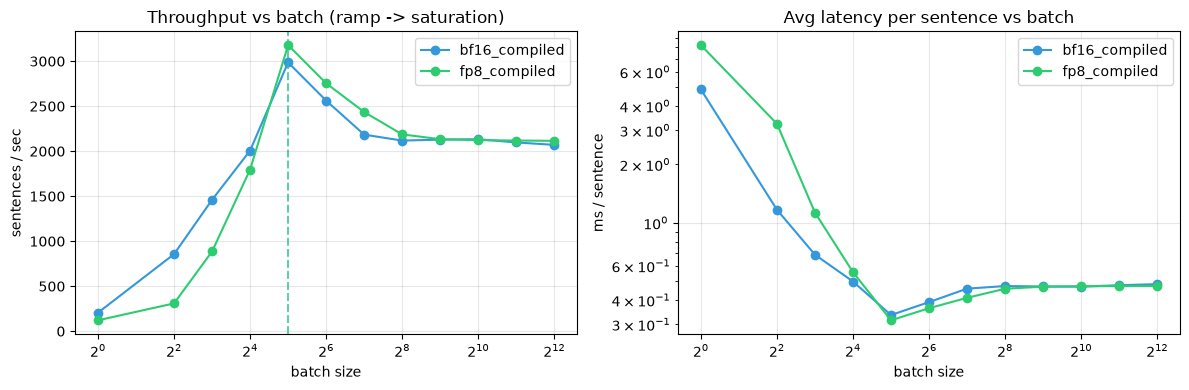

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = {"bf16_compiled": "#3498DB", "fp8_compiled": "#2ECC71"}
for name, rs in results.items():
    if not rs:
        continue
    b = sorted(rs)
    ax1.plot(b, [rs[x]["sent_per_s"] for x in b], "o-", color=colors.get(name), label=name)
    ax2.plot(b, [rs[x]["ms_per_sent"] for x in b], "o-", color=colors.get(name), label=name)
    if name in summary:
        ax1.axvline(summary[name]["saturation_batch"], color=colors.get(name), ls="--", alpha=0.5)
ax1.set_xscale("log", base=2); ax1.set_xlabel("batch size"); ax1.set_ylabel("sentences / sec")
ax1.set_title("Throughput vs batch (ramp -> saturation)"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.set_xscale("log", base=2); ax2.set_yscale("log"); ax2.set_xlabel("batch size")
ax2.set_ylabel("ms / sentence"); ax2.set_title("Avg latency per sentence vs batch"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Save

Persists the full curve and the saturation summary for both schemes.

In [10]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUT_PATH.write_text(json.dumps({
    "model": MODEL_NAME, "seq": SEQ,
    "curve": {name: {str(b): rs[b] for b in rs} for name, rs in results.items()},
    "saturation": summary,
}, indent=2, default=float))
rprint(f"[dark_sea_green]✓[/dark_sea_green] saved → [dim]{OUT_PATH}[/dim]")

✓ saved → /home/lab/workspace/learning/projects/docdistance-estimator/reports/03-mmbert-throughput-saturation.json